<a href="https://colab.research.google.com/github/gauravkunwarr/InceptionV3/blob/main/sugarcane_leaf_disease_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
# Create a folder named "dataset"
os.makedirs("dataset", exist_ok=True)

# Path to the zip file (adjust if the file is located elsewhere)
zip_path = "/content/drive/MyDrive/project/archive.zip"

# Extract the zip file into the "dataset" folder

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall("dataset")

In [ ]:
import numpy as np  # Importing the library numpy as np
import random  # Importing the module named random
import cv2  # The OpenCV library is imported as cv2
from imblearn.over_sampling import SMOTE  # The SMOTE class is also imported from the python library imblearn.over_sampling
from tqdm import tqdm  # For the progress bar importing the tqdm module
import glob  # The glob module is also being imported for the process of file path matching
from tensorflow import keras  # Importing the machine learning lybrary named tensorflow.keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # From sklearn.metrics Imported the evaluation metrics
#  The Pooling layer for Global average
from sklearn.metrics import confusion_matrix, classification_report  # Importing confusion_matrix and classification_report from sklearn.metrics
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, concatenate
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn import metrics  # Importing metrics module from sklearn
import matplotlib.image as mpimg
import matplotlib.pyplot as matp_lib
import seaborn as sns

In [ ]:
# load image files from the dataset

Sugarcane_Leaf_Disease_df = [f for f in glob.glob('/content/dataset/' + "/**/*", recursive=True) if not os.path.isdir(f)]

# Shuffle the list of file paths randomly

random.shuffle(Sugarcane_Leaf_Disease_df)

In [ ]:
Sugarcane_Leaf_Disease_df

['/content/dataset/Mosaic/mosaic (157).jpeg',
 '/content/dataset/Healthy/healthy (125).jpeg',
 '/content/dataset/Healthy/healthy (213).jpeg',
 '/content/dataset/Yellow/yellow (141).jpeg',
 '/content/dataset/Rust/rust (281).jpeg',
 '/content/dataset/Healthy/healthy (37).jpeg',
 '/content/dataset/Yellow/yellow (450).jpeg',
 '/content/dataset/RedRot/redrot (214).jpeg',
 '/content/dataset/Healthy/healthy (278).jpeg',
 '/content/dataset/RedRot/redrot (46).jpeg',
 '/content/dataset/Rust/rust (451).jpeg',
 '/content/dataset/Mosaic/mosaic (450).jpeg',
 '/content/dataset/Rust/rust (428).jpeg',
 '/content/dataset/Rust/rust (445).jpeg',
 '/content/dataset/Mosaic/mosaic (14).jpeg',
 '/content/dataset/Healthy/healthy (241).jpeg',
 '/content/dataset/RedRot/redrot (195).jpeg',
 '/content/dataset/Rust/rust (290).jpeg',
 '/content/dataset/Yellow/yellow (258).jpeg',
 '/content/dataset/Rust/rust (410).jpeg',
 '/content/dataset/Rust/rust (494).jpeg',
 '/content/dataset/Mosaic/mosaic (286).jpeg',
 '/conten

#  show 10 images with label

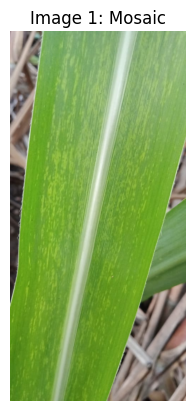

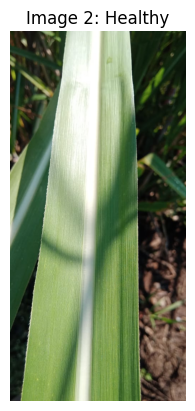

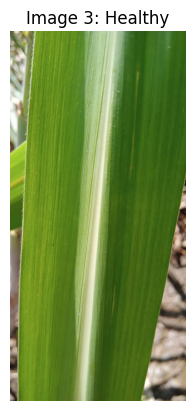

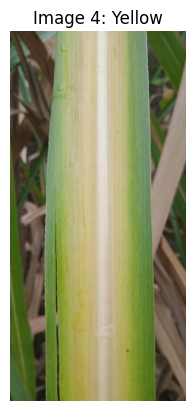

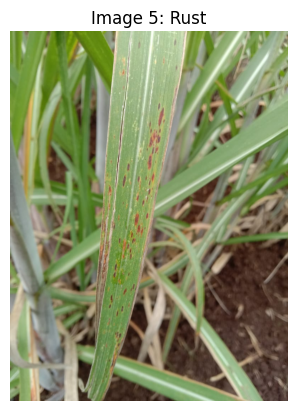

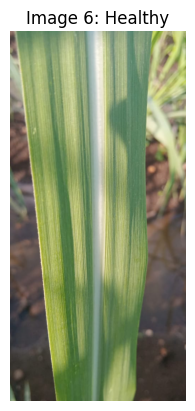

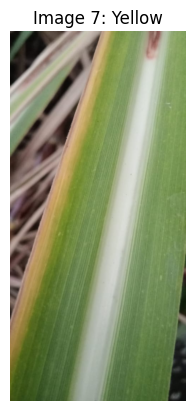

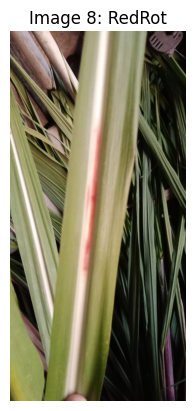

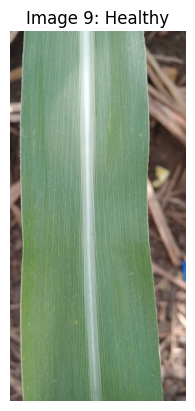

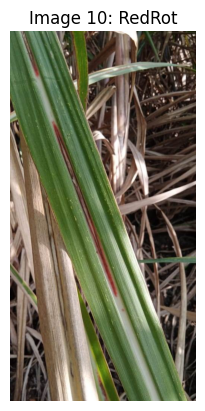

In [ ]:
#  Sugarcane_Leaf_Disease_df contains file paths to images

for i in range(10):

  image_path = Sugarcane_Leaf_Disease_df[i]

  try:

    img = mpimg.imread(image_path)

    matp_lib.imshow(img)

    matp_lib.title(f"Image {i+1}: {image_path.split('/')[-2]}") # Extract label from path

    matp_lib.axis('off')

    matp_lib.show()

  except Exception as e:

    print(f"Error displaying image {image_path}: {e}")

The process of methods applied for image sugarcane leaf diseases pre-processing on machine learning. Reads each image in the dataset, applies image enhancement using CLAHE on the LAB color space, reduces the noise with Gaussian blur, normalizes pixel values to the range [0, 1], and resizes the image to 224x224 pixels. It then goes ahead to extract the class label, for example "Healthy," "Mosaic, from the file path assign numeric labels 0–4 based on the class, and store both the preprocessed image in the data list and its corresponding label in the labels list.

In [ ]:
data = []
labels = []

for i in tqdm(range(len(Sugarcane_Leaf_Disease_df))):
    img = cv2.imread(Sugarcane_Leaf_Disease_df[i])
    # Convert the image to LAB color space for CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    # Apply CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    # Merge the enhanced L-channel back with A and B channels
    lab = cv2.merge((cl, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    # Apply Gaussian filtering for noise reduction
    img = cv2.GaussianBlur(img, (5, 5), 0)
    # Normalize pixel values to the range [0, 1]
    img = img / 255.0
    # Resize the image to 224x224
    img = cv2.resize(img, (224, 224))
    # Append the preprocessed image to the data list
    data.append(img)
    # Extract the class label from the file path
    cls = Sugarcane_Leaf_Disease_df[i].split(os.path.sep)[-2]

    if cls == 'Healthy':

        lbl = 0

    elif cls == 'Mosaic':

        lbl = 1

    elif cls == 'RedRot':

        lbl = 2

    elif cls == 'Rust':

        lbl = 3

    elif cls == 'Yellow':

        lbl = 4

    labels.append(lbl)


100%|██████████| 2521/2521 [00:51<00:00, 48.66it/s]


In [ ]:
# Convert 'data' to a NumPy array
data = np.array(data)
# Convert 'labels' to a NumPy array
labels = np.array(labels)

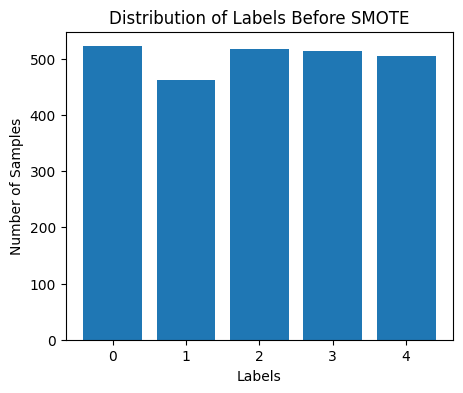

In [ ]:
unique_labels, label_counts = np.unique(labels, return_counts=True)
matp_lib.figure(figsize=(5, 4))

matp_lib.bar(unique_labels, label_counts)

matp_lib.xlabel("Labels")

matp_lib.ylabel("Number of Samples")

matp_lib.title("Distribution of Labels Before SMOTE")

matp_lib.xticks(unique_labels)

matp_lib.show()


It calculates the total number of pixels per image by multiplying the height, width, and channels of the images in the dataset and then converts the images into one-dimensional arrays while preserving the number of samples such that data can be used to do oversampling. SMOTE (Synthetic Minority Over-sampling Technique) ensures class balance through synthetic oversampling for the class or classes which are underrepresented. After oversampling, the flattened data are reshaped back to the original image dimensions of 224x224x3 to preserve the structure of the image for further processing or model training.

In [ ]:
# Calculate the shape of the -data

data_shape = data.shape[1] * data.shape[2] * data.shape[3]

# Reshape the -data to -flatten it while-preserving -the -number of -samples

data = data.reshape(data.shape[0], data_shape)

# Apply SMOTE for oversampling

over_smp = SMOTE()

data, labels = over_smp.fit_resample(data, labels)

# Reshape the data back to its original shape after oversampling

for i in range(len(data)):

    data = data.reshape(len(data), 224, 224, 3)  # the original shape was (224, 224, 3)


In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.image as mpimg
Xtrain_Sugarcane_Leaf_Disease_df, Xtest_Sugarcane_Leaf_Disease_df, ytrain_Sugarcane_Leaf_Disease_df, ytest_Sugarcane_Leaf_Disease_df = train_test_split(data, labels, test_size=0.2, random_state=42)

In [ ]:
print("X_train  shape:", Xtrain_Sugarcane_Leaf_Disease_df.shape)

print("X_test shape:", Xtest_Sugarcane_Leaf_Disease_df.shape)

print("y_train  shape:", ytrain_Sugarcane_Leaf_Disease_df.shape)

print("y_test  shape:", ytest_Sugarcane_Leaf_Disease_df.shape)

X_train shape: (2088, 224, 224, 3)
X_test shape: (522, 224, 224, 3)
y_train shape: (2088,)
y_test shape: (522,)


In [ ]:
from tensorflow.keras.utils import to_categorical
ytrain_Sugarcane_Leaf_Disease_df = to_categorical(ytrain_Sugarcane_Leaf_Disease_df, num_classes=5) #  5 classes
ytest_Sugarcane_Leaf_Disease_df = to_categorical(ytest_Sugarcane_Leaf_Disease_df, num_classes=5)
print("y_train  shape:", ytrain_Sugarcane_Leaf_Disease_df.shape)
print("y_test  shape:", ytest_Sugarcane_Leaf_Disease_df.shape)

y_train shape: (2088, 5)
y_test shape: (522, 5)


#IncepNet-MobiFusion

IncepNet-MobiFusion deep learning model is formed by combining two pre-trained models, InceptionV3 and MobileNet, excluding their top classification layers. The base models are frozen to retain the pre-trained weights. Both the outputs are adapted using custom adaptive layers, namely Global Average Pooling. Finally, these outputs are concatenated and pass through fully connected layers with ReLU activations and dropout for regularization. The output layer has softmax activation with 5 classes, which represent the classifications of sugarcane leaf diseases. The model is compiled with an Adam optimizer, low learning rate, categorical cross-entropy loss, and accuracy as the evaluation metric. Finally, the model's architecture is printed.

In [ ]:
# Load pre-trained InceptionV3 and MobileNet models (excluding top layers)
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base models to retain pre-trained weights
for layer in inception_base.layers:
    layer.trainable = False

for layer in mobilenet_base.layers:
    layer.trainable = False

# Add custom adaptive layers to both models
inception_output = inception_base.output
inception_output = GlobalAveragePooling2D()(inception_output)

mobilenet_output = mobilenet_base.output
mobilenet_output = GlobalAveragePooling2D()(mobilenet_output)

# Combine the outputs from both models
combined = concatenate([inception_output, mobilenet_output])

# Add fully connected layers on top of the combined features
x = Dense(1020, activation='relu')(combined)
x = Dropout(0.5)(x)  # Add dropout to reduce overfitting
x = Dense(1020, activation='relu')(x)
x = Dropout(0.5)(x)

# Add the final output layer
output = Dense(5, activation='softmax')(x)  # Adjust the number of classes for your dataset

# Build the final model
IncepNet_MobiFusion_model = Model(inputs=[inception_base.input, mobilenet_base.input], outputs=output)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
# Compile the model
IncepNet_MobiFusion_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
IncepNet_MobiFusion_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 29,212,633 (111.44 MB)

 Trainable params: 4,180,985 (15.95 MB)

 Non-trainable params: 25,031,648 (95.49 MB)

implements K-fold cross-validation with 3 splits to train a hybrid model. It begins by transforming training data, Xtrain_Sugarcane_Leaf_Disease_df and ytrain_Sugarcane_Leaf_Disease_df into NumPy arrays to be compatible with KFold. Initialization of the KFold object occurs with 3 splits and shuffle=True to make sure that the samples will be in random order. On every iteration for each fold, it subdivides both training and validation datasets with the indices returned by KFold. The data is formatted into a list of two identical sets for both input branches: InceptionV3 and MobileNet. It is trained on the training subset and validated on the validation subset over 10 epochs with a batch size of 132. The fold histories are saved for each fold in the fold_histories to be accessed later for analysis.

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# Convert Xtrain_Sugarcane_Leaf_Disease_df to a NumPy array for splitting
Xtrain_Sugarcane_Leaf_Disease_df_np = np.array(Xtrain_Sugarcane_Leaf_Disease_df)  # Replace with appropriate data format if necessary
ytrain_Sugarcane_Leaf_Disease_df_np = np.array(ytrain_Sugarcane_Leaf_Disease_df)  # Replace with appropriate data format if necessary

# Initialize KFold with 3 splits
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# List to store the histories of each fold
fold_histories = []

# Iterate over each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(Xtrain_Sugarcane_Leaf_Disease_df_np)):
    print(f"Starting fold {fold + 1}")

    # Split data into train and validation sets for this fold
    Xtrain_Sugarcane_Leaf_Disease_df = Xtrain_Sugarcane_Leaf_Disease_df_np[train_idx]
    ytrain_Sugarcane_Leaf_Disease_df = ytrain_Sugarcane_Leaf_Disease_df_np[train_idx]
    X_val = Xtrain_Sugarcane_Leaf_Disease_df_np[val_idx]
    y_val = ytrain_Sugarcane_Leaf_Disease_df_np[val_idx]

    # Create input data for both branches
    Xtrain_Sugarcane_Leaf_Disease_df = [Xtrain_Sugarcane_Leaf_Disease_df, Xtrain_Sugarcane_Leaf_Disease_df]
    X_val = [X_val, X_val]

    # Train the model for this fold
    history = IncepNet_MobiFusion_model.fit(
        Xtrain_Sugarcane_Leaf_Disease_df, ytrain_Sugarcane_Leaf_Disease_df,
        epochs=10,
        batch_size=132,
        validation_data=(X_val, y_val),
        verbose=1
    )

Starting fold 1
Epoch 1/10


I0000 00:00:1732547887.487823    6219 service.cc:145] XLA service 0x7ed5ec006500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1732547887.487873    6219 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 1/11 ━━━━━━━━━━━━━━━━━━━━ 4:50 29s/step - accuracy: 0.1667 - loss: 2.2504

I0000 00:00:1732547907.396186    6219 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.2293 - loss: 1.9507 - val_accuracy: 0.6006 - val_loss: 1.1509
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.4481 - loss: 1.3481 - val_accuracy: 0.6724 - val_loss: 0.9618
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.5842 - loss: 1.0775 - val_accuracy: 0.6911 - val_loss: 0.8436
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step - accuracy: 0.6207 - loss: 0.9697 - val_accuracy: 0.7256 - val_loss: 0.7454
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 0.6792 - loss: 0.8464 - val_accuracy: 0.7543 - val_loss: 0.6852
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.7172 - loss: 0.7597 - val_accuracy: 0.7658 - val_loss: 0.6305
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - accuracy: 0.7474 - loss: 0.6728 - val_accuracy: 0.7874 - val_loss: 0.5843
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step - accuracy: 0.7887 - loss: 0.5953 - val_accuracy: 0.7917 - val_lo

#plot accuracy and loss graph

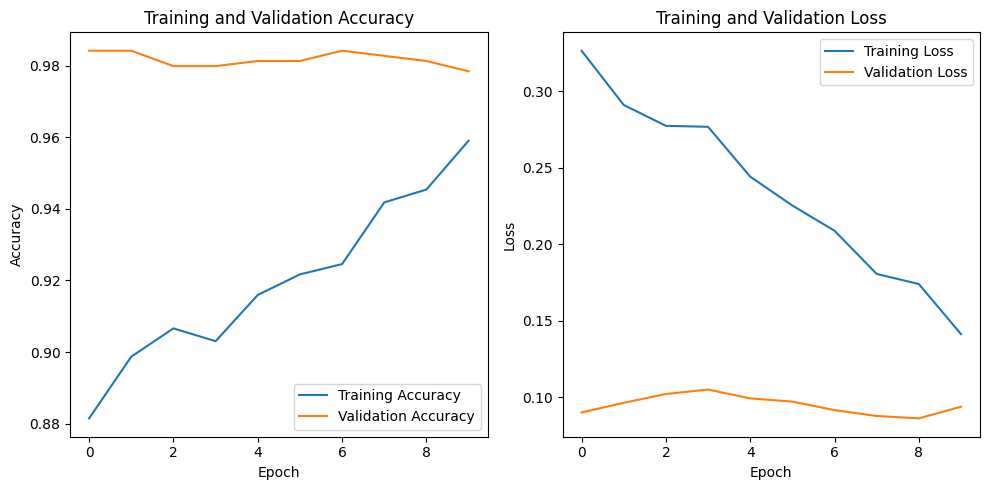

In [ ]:
#  plot accuracy or loss graph
matp_lib.figure(figsize=(10, 5))
matp_lib.subplot(1, 2, 1)

matp_lib.plot(history.history['accuracy'], label='Training Accuracy')

matp_lib.plot(history.history['val_accuracy'], label='Validation Accuracy')

matp_lib.xlabel('Epoch')

matp_lib.ylabel('Accuracy')

matp_lib.legend()

matp_lib.title('Training and Validation Accuracy')

matp_lib.subplot(1, 2, 2)

matp_lib.plot(history.history['loss'], label='Training Loss')

matp_lib.plot(history.history['val_loss'], label='Validation Loss')

matp_lib.xlabel('Epoch')

matp_lib.ylabel('Loss')

matp_lib.legend()

matp_lib.title('Training and Validation Loss')

matp_lib.tight_layout()

matp_lib.show()

#Training results:

# Calculate metrics for each class

In [ ]:

# Predict on training data
y_pred_train = IncepNet_MobiFusion_model.predict(Xtrain_Sugarcane_Leaf_Disease_df)
y_pred_train = np.argmax(y_pred_train, axis=1)  # Convert probabilities to class labels
y_true_train = np.argmax(ytrain_Sugarcane_Leaf_Disease_df, axis=1)  # Convert one-hot encoded labels back to class labels


print("Metrics for Each Class:")
for class_label in range(5):  # Assuming 5 classes (0 to 4)
    y_true_class = (y_true_train == class_label)
    y_pred_class = (y_pred_train == class_label)

    precision = precision_score(y_true_class, y_pred_class, zero_division=1)
    recall = recall_score(y_true_class, y_pred_class, zero_division=1)
    f1 = f1_score(y_true_class, y_pred_class, zero_division=1)

    print(f"Class {class_label}:")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-score: {f1:.2f}")

# Calculate overall metrics
train_accuracy = accuracy_score(y_true_train, y_pred_train)
train_precision = precision_score(y_true_train, y_pred_train, average='weighted')
train_recall = recall_score(y_true_train, y_pred_train, average='weighted')
train_f1 = f1_score(y_true_train, y_pred_train, average='weighted')

print("\nOverall Training Metrics:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1-score: {train_f1:.2f}")


44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step
Metrics for Each Class:
Class 0:
  Precision: 0.98
  Recall: 1.00
  F1-score: 0.99
Class 1:
  Precision: 0.99
  Recall: 0.99
  F1-score: 0.99
Class 2:
  Precision: 1.00
  Recall: 0.98
  F1-score: 0.99
Class 3:
  Precision: 1.00
  Recall: 1.00
  F1-score: 1.00
Class 4:
  Precision: 0.99
  Recall: 0.99
  F1-score: 0.99

Overall Training Metrics:
Training Accuracy: 0.99
Training Precision: 0.99
Training Recall: 0.99
Training F1-score: 0.99


# plot confusion matrix  for training

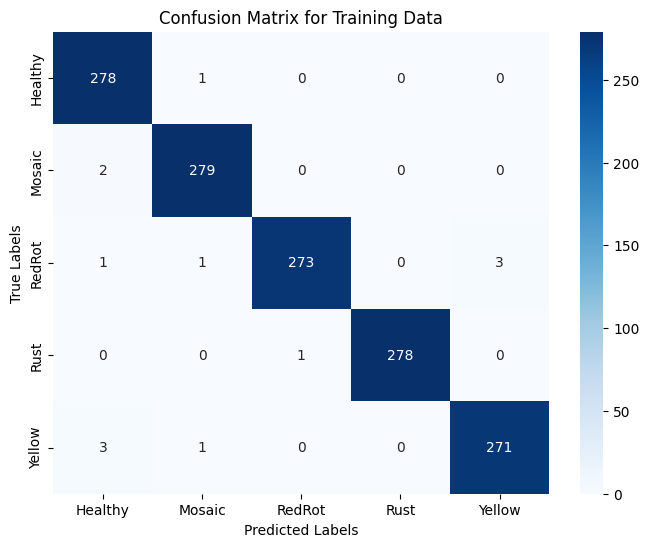

In [ ]:
#  y_true_train and y_pred_train are defined as in your previous code
cm = confusion_matrix(y_true_train, y_pred_train)
matp_lib.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            xticklabels=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'],

            yticklabels=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'])

matp_lib.xlabel('Predicted Labels')

matp_lib.ylabel('True Labels')

matp_lib.title('Confusion Matrix for Training Data')

matp_lib.show()

#  classification report

In [ ]:
report = classification_report(y_true_train, y_pred_train, target_names=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'], digits=4)

print(report)


              precision    recall  f1-score   support

     Healthy     0.9789    0.9964    0.9876       279
      Mosaic     0.9894    0.9929    0.9911       281
      RedRot     0.9964    0.9820    0.9891       278
        Rust     1.0000    0.9964    0.9982       279
      Yellow     0.9891    0.9855    0.9872       275

    accuracy                         0.9907      1392
   macro avg     0.9907    0.9906    0.9907      1392
weighted avg     0.9907    0.9907    0.9907      1392



#TESTING

# Calculate metrics for each class

In [ ]:

y_pred_test = IncepNet_MobiFusion_model.predict(X_val)

y_pred_test = np.argmax(y_pred_test, axis=1)  # Convert probabilities to class labels

y_true_test = np.argmax(y_val, axis=1)  # Convert one-hot encoded labels back to class labels

for class_label in range(5):  # Assuming 5 classes (0 to 4)

    y_true_class = (y_true_test == class_label)

    y_pred_class = (y_pred_test == class_label)

    precision = precision_score(y_true_class, y_pred_class)

    recall = recall_score(y_true_class, y_pred_class)

    f1 = f1_score(y_true_class, y_pred_class)

    print(f"Class {class_label}:")

    print(f"  Precision: {precision}")

    print(f"  Recall: {recall}")

    print(f"  F1-score: {f1}")

# Calculate the test metrics (overall)

test_accuracy = accuracy_score(y_true_test, y_pred_test)

test_precision = precision_score(y_true_test, y_pred_test, average='weighted')  # Use 'weighted' for multi-class

test_recall = recall_score(y_true_test, y_pred_test, average='weighted')

test_f1 = f1_score(y_true_test, y_pred_test, average='weighted')

print("\nOverall Test Metrics:")

print("Test Accuracy:", test_accuracy)

print("Test Precision:", test_precision)

print("Test Recall:", test_recall)

print("Test F1-score:", test_f1)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 367ms/step
Class 0:
  Precision: 0.9699248120300752
  Recall: 1.0
  F1-score: 0.9847328244274809
Class 1:
  Precision: 0.9923664122137404
  Recall: 0.9629629629629629
  F1-score: 0.9774436090225563
Class 2:
  Precision: 0.9857142857142858
  Recall: 0.9583333333333334
  F1-score: 0.971830985915493
Class 3:
  Precision: 0.9867549668874173
  Recall: 0.9933333333333333
  F1-score: 0.9900332225913622
Class 4:
  Precision: 0.9574468085106383
  Recall: 0.9782608695652174
  F1-score: 0.967741935483871

Overall Test Metrics:
Test Accuracy: 0.978448275862069
Test Precision: 0.9786975979183513
Test Recall: 0.978448275862069
Test F1-score: 0.9784230661300283


# plot confution matrix

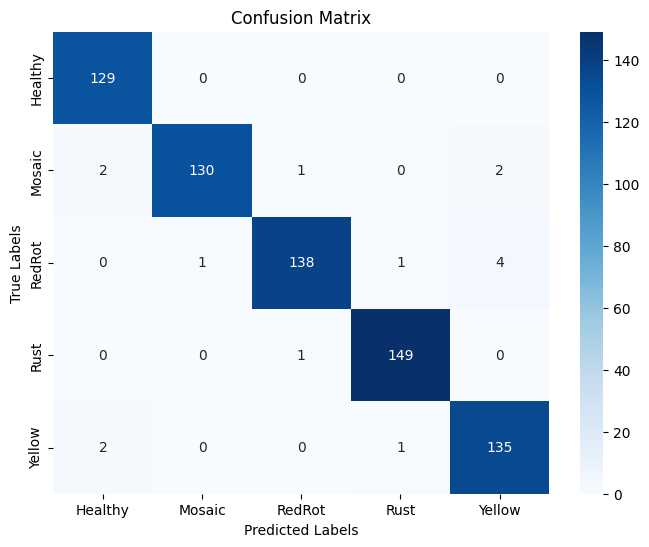

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)

matp_lib.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",

            xticklabels=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'],

            yticklabels=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'])

matp_lib.xlabel("Predicted Labels")

matp_lib.ylabel("True Labels")

matp_lib.title("Confusion Matrix")

matp_lib.show()

#  classification report

In [ ]:
report = classification_report(y_true_test, y_pred_test, target_names=['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow'], digits=4)

print(report)

              precision    recall  f1-score   support

     Healthy     0.9699    1.0000    0.9847       129
      Mosaic     0.9924    0.9630    0.9774       135
      RedRot     0.9857    0.9583    0.9718       144
        Rust     0.9868    0.9933    0.9900       150
      Yellow     0.9574    0.9783    0.9677       138

    accuracy                         0.9784       696
   macro avg     0.9784    0.9786    0.9784       696
weighted avg     0.9787    0.9784    0.9784       696



# Get predictions for the first 5 images in the test set

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


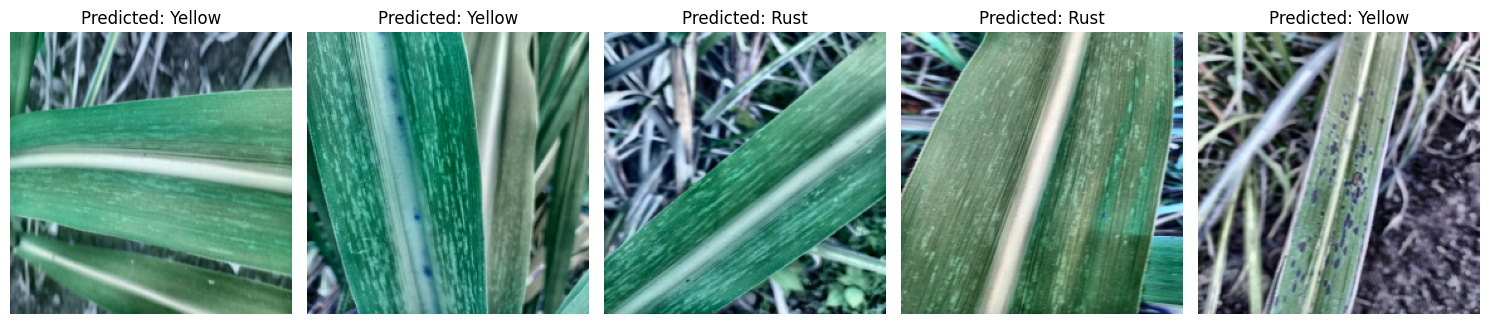

In [ ]:
predictions = IncepNet_MobiFusion_model.predict(X_val[:5])

# Get the predicted class labels (the class with the highest probability)
predicted_classes = np.argmax(predictions, axis=1)

# Define class names
class_names = ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']

# Plot the first 5 images with their predicted labels
matp_lib.figure(figsize=(15, 8))
for i in range(5):
    matp_lib.subplot(1, 5, i + 1)  # Create subplots
    matp_lib.imshow(Xtest_Sugarcane_Leaf_Disease_df[i])    # Show the image
    matp_lib.axis('off')          # Turn off the axis
    matp_lib.title(f"Predicted: {class_names[predicted_classes[i]]}")  # Add title with predicted class

matp_lib.tight_layout()
matp_lib.show()
